# LCLIB Example

In this notebook we look at how we could take light curves from a LCLIB file and simulate them under different observing cadences and noise conditions.

In [1]:
import numpy as np

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR
from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.noise_models.base_noise_models import ConstantFluxNoiseModel
from lightcurvelynx.obstable.location_free_obstable import LocationFreeObsTable
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
from lightcurvelynx.models.lightcurve_template_model import MultiLightcurveTemplateModel
from lightcurvelynx.utils.plotting import plot_lightcurves

## Load Data Files

We start by loading the files we will need for running the simulation: the OpSim database and the passband information. Both of these live in the `data/` directory in the root directory. Note that nothing in this directory is saved to github, so the files might have to be downloaded initially.

For Rubin, a large number of OpSims can be found at [https://s3df.slac.stanford.edu/data/rubin/sim-data/](https://s3df.slac.stanford.edu/data/rubin/sim-data/). You can download an OpSim manually or using the `from_url()` helper function:

> opsim_url = "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs5.3/baseline/baseline_v5.3.0_10yrs.db"

> opsim_data = OpSim.from_url(opsim_url)

We only care about the observations in the OpSim in the filters we wish to simulate. So we use `OpSim.filter_rows()` to remove those rows that do not match.

In [2]:
# Choose which filters to simulate.
filters = ["g", "r", "i", "z"]

# Load the OpSim data.
opsim_db = OpSim.from_db(_LIGHTCURVELYNX_BASE_DATA_DIR / "opsim" / "baseline_v5.3.0_10yrs.db")
print(f"Loaded OpSim with {len(opsim_db)} rows.")

# Filter to only the rows that match the filters we want to simulate.
filter_mask = np.isin(opsim_db["filter"], filters)
opsim_db = opsim_db.filter_rows(filter_mask)

# Print the number of rows and time bounds after filtering.
t_min, t_max = opsim_db.time_bounds()
print(f"Filtered OpSim to {len(opsim_db)} rows and times [{t_min}, {t_max}]")

Loaded OpSim with 1844571 rows.
Filtered OpSim to 1421879 rows and times [61208.42731204634, 64860.44487408427]


## Create the model

We want to create models based on an existing LCLIB file. Again we will need to download the file of interest to the data directory.  In this example we use the LCLIB_RRL-LSST.TEXT.gz data from https://zenodo.org/records/6672739.  We load this into a `MultiLightcurveTemplateModel` object, which represents a set of light curves from which we can sample.

The `MultiLightcurveTemplateModel` stores a series of multi-band light curves, each corresponding to the observer frame bandfluxes for a single real or simulated objects. New observations are created by randomly choosing one of the light curves and interpolating it at new times. The starting time of the activity is controlled by the `t0` parameter in the model. So we can generate a simulation where the object's activity starts halfway through our observations.

Note that currently only periodic and non-reoccurring non-periodic light curves are supported. We treat reoccurring non-periodic light curves as non-reoccurring non-periodic (they will only occur once in the simulated output).

Since `MultiLightcurveTemplateModel` is a `PhysicalModel`, we can specify other parameters such as the RA and dec.  In this examples, we generate this position information by sampling from the OpSim fields (using an `ObsTableRADECSampler` node). We sample the starting time of the light curve uniformly from the time covered by the OpSim.

In [3]:
lc_file = _LIGHTCURVELYNX_BASE_DATA_DIR / "model_files" / "LCLIB_RRL-LSST.TEXT.gz"

# Use an OpSim based sampler for position.
ra_dec_sampler = ObsTableRADECSampler(
    opsim_db,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

# Use a uniform sampler for the starting time (t0) of activity.
time_sampler = NumpyRandomFunc("uniform", low=t_min, high=t_max, node_label="time_sampler")

# Load the light curves from the LCLIB file. Only load the filters that are present in the OpSim data.
source = MultiLightcurveTemplateModel.from_lclib_file(
    lc_file,
    None,  # We don't need the filter info since we are simulating at the passband level.
    ra=ra_dec_sampler.ra,
    dec=ra_dec_sampler.dec,
    t0=time_sampler,
    filters=filters,
    node_label="source",
)

print(f"Loaded {len(source)} light curves from {lc_file}")

Loading: 49130lc [00:20, 2396.68lc/s]

Loaded 49130 light curves from /Users/jkubica/h/lightcurvelynx/data/model_files/LCLIB_RRL-LSST.TEXT.gz


## Generate the simulations

We can now generate random simulations with all the information defined above. The `simulate_lightcurves` function takes three parameters: the source from which we want to sample (here the collection of lightcurves), the number of results to simulate (1,000), and the survey information.

Note: The survey information will load the default passbands for the LSST survey, but they will not be used since the model is creating simulations at the bandflux level.

In [4]:
survey_info = SurveyInfo(obstable=opsim_db, survey_name="LSST")
lightcurves = simulate_lightcurves(source, 1_000, survey_info)

Simulating: 100%|██████████| 1000/1000 [00:00<00:00, 1156.35obj/s]


The results are written in the [nested-pandas](https://github.com/lincc-frameworks/nested-pandas) format for easy analysis. Each row corresponds to a single simulated object, with a unique id, ra, dec, etc. The column `params` include all internal state, including hyperparameter settings, that was used to generate this object.

We can print the first row:

In [5]:
print(lightcurves.loc[0])

id                                                            0
ra                                                    74.209123
dec                                                  -65.543038
nobs                                                        565
t0                                                 61294.358319
z                                                          None
lightcurve                  mjd filter          flux      fl...
params        {'NumpyRandomFunc:integers_2.low': 0, 'NumpyRa...
Name: 0, dtype: object


The nested `lightcurve` column contains the times, filters, and fluxes for each observation of that object.  We can treat it as a table:

In [6]:
print(lightcurves.loc[0]["lightcurve"])

              mjd filter          flux      fluxerr  flux_perfect  survey_idx  \
0    61315.377326      z  94018.782955   511.353686  94149.390837           0   
1    61316.381922      r  89401.985795   265.431294  89456.491436           0   
..            ...    ...           ...          ...           ...         ...   
563  64805.019957      r  82579.710139   262.387486  82336.605956           0   
564  64854.442297      z  67714.679931  2161.036012  67087.010259           0   

     obs_idx  is_saturated  
0      26267         False  
1      27080         False  
..       ...           ...  
563  1396712         False  
564  1421513         False  

[565 rows x 8 columns]


Now let's plot some random light curves. Note that all of the light curves in the "LCLIB_RRL-LSST.TEXT.gz" file are periodic, so we expect to see observations throughout the time range of the survey.

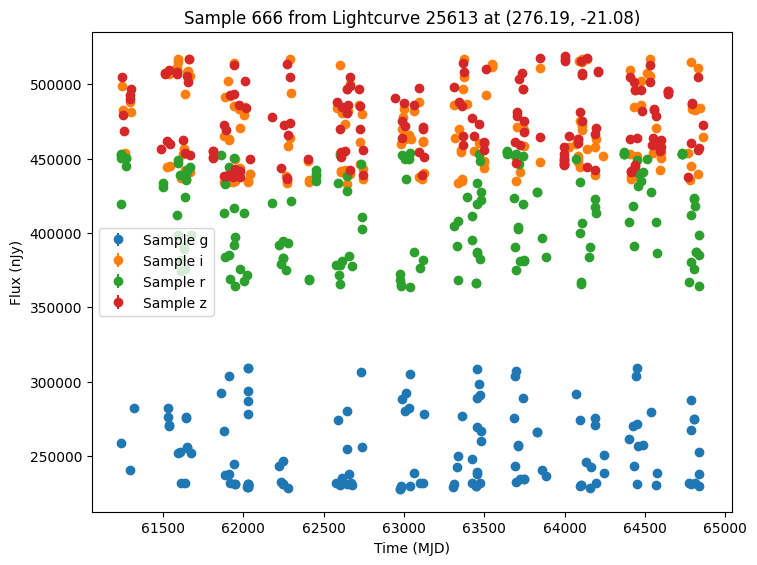

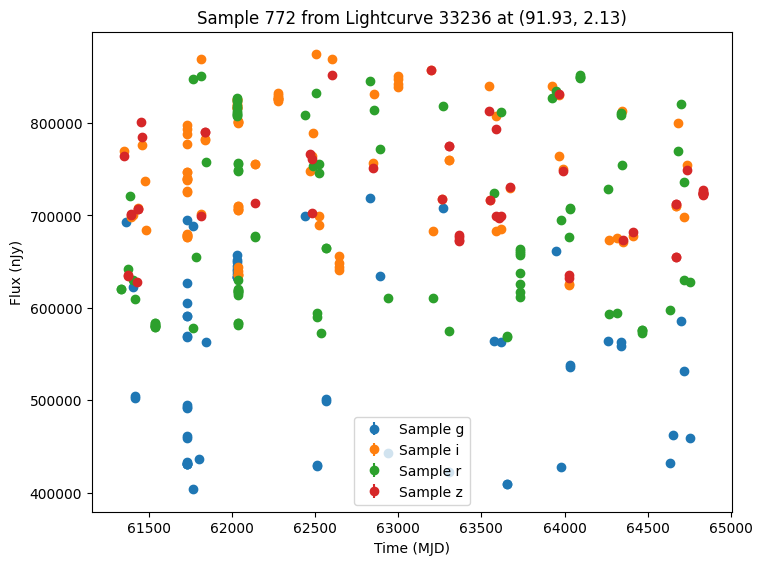

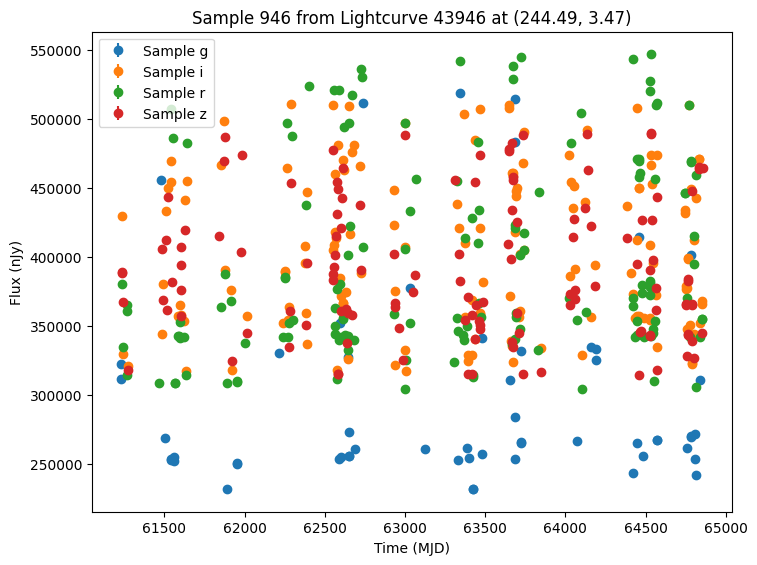

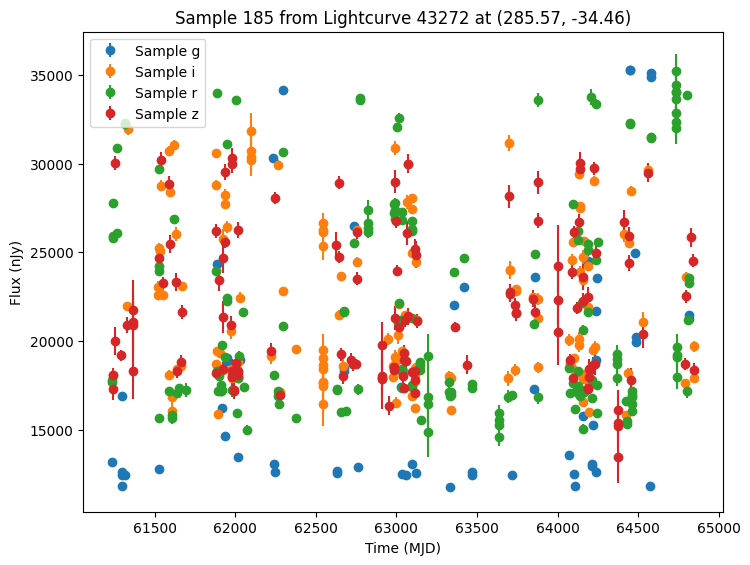

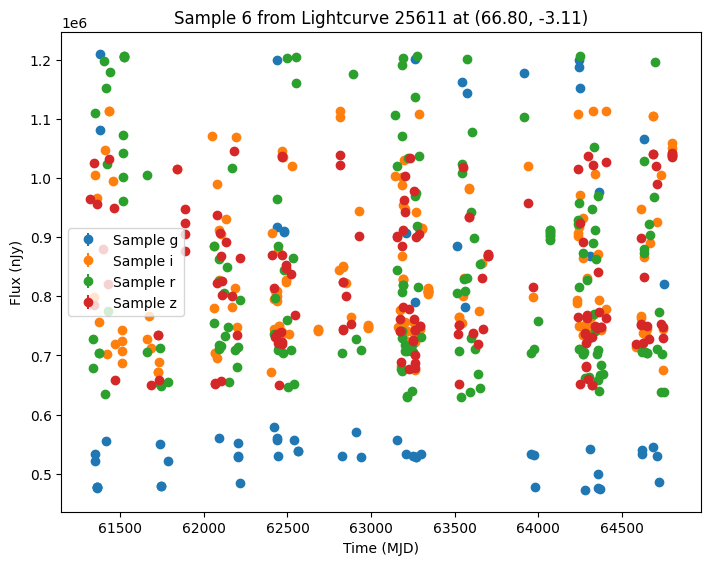

In [7]:
def plot_some_lightcurves(lightcurve_data, indices):
    for id in indices:
        # Extract the row for this object.
        lc = lightcurve_data.loc[id]

        if lc["nobs"] > 0:
            # Unpack the nested columns (filters, mjd, flux, and flux error).
            lc_filters = np.asarray(lc["lightcurve"]["filter"], dtype=str)
            lc_mjd = np.asarray(lc["lightcurve"]["mjd"], dtype=float)
            lc_flux = np.asarray(lc["lightcurve"]["flux"], dtype=float)
            lc_fluxerr = np.asarray(lc["lightcurve"]["fluxerr"], dtype=float)

            # Look up which lightcurve was used.
            graph_state = lc["params"]
            lc_id = graph_state["source.selected_lightcurve"]
            ra = graph_state["source.ra"]
            dec = graph_state["source.dec"]

            plot_lightcurves(
                fluxes=lc_flux,
                times=lc_mjd,
                fluxerrs=lc_fluxerr,
                filters=lc_filters,
                title=f"Sample {id} from Lightcurve {lc_id} at ({ra:.2f}, {dec:.2f})",
            )


random_ids = np.random.choice(len(lightcurves), 5)
plot_some_lightcurves(lightcurves, random_ids)

## Comparing with Another Survey

We can view how these light curves would look under a different survey cadence. Let's consider a `LocationFreeObsTable` which does not filter on spatial position. Instead it sees all objects at given time steps and in give filters.

We will use daily visits in each of "r", "g", and "i" for the first 100 days covered by the opsim.

In [8]:
num_new_days = 100

# Three observations per day, with a small offset for each observation.
offsets = np.tile([0.0, 0.05, 0.1], num_new_days)
base = np.repeat(np.arange(num_new_days) + t_min, 3)
new_times = base + offsets

# Repeat the same 3 filters each day
filters = np.tile(["g", "r", "i"], num_new_days)

data = {"time": new_times, "filter": filters}
no_location_obs_table = LocationFreeObsTable(data)

Because we want to re-run the simulation on exactly the same light curves for comparison, we can extract the `GraphState` from the previous simulation results. We pass this extracted state to the simulate function to generate new simulations with the new survey information and exactly the same model parameters.

Because we used a `LocationFreeObsTable` every object will be seen exactly three times a night (once in each band).

In [9]:
# Extract the previous model parameters.
previous_state = GraphState.from_list(lightcurves["params"].values)

# Re-run the simulation with the new observation table and the previous model parameters.
new_survey_info = SurveyInfo(
    obstable=no_location_obs_table,
    noise_model=ConstantFluxNoiseModel(0.0),  # No noise for the new observations.
    survey_name="LSST",
)

lightcurves_new_obs = simulate_lightcurves(source, 1_000, new_survey_info, graph_state=previous_state)

Simulating: 100%|██████████| 1000/1000 [00:00<00:00, 6334.32obj/s]


We can plot the same 5 samples as before. Note these sources have the same parameters and thus can be compared directly.

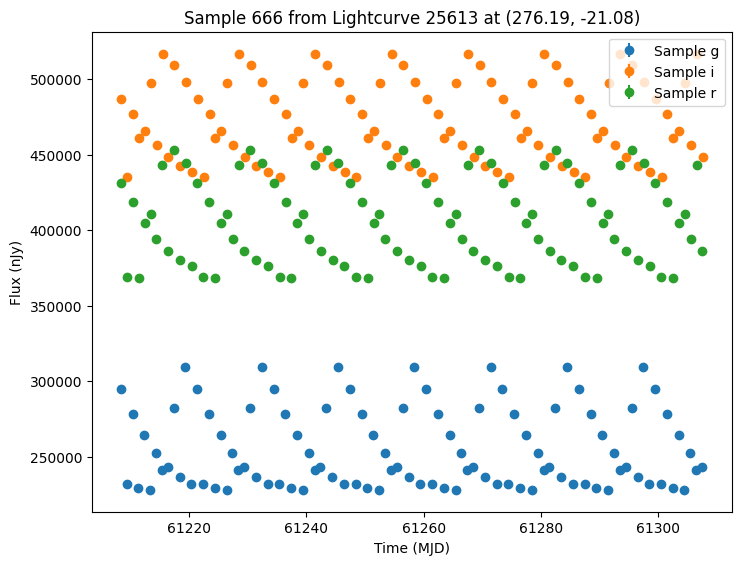

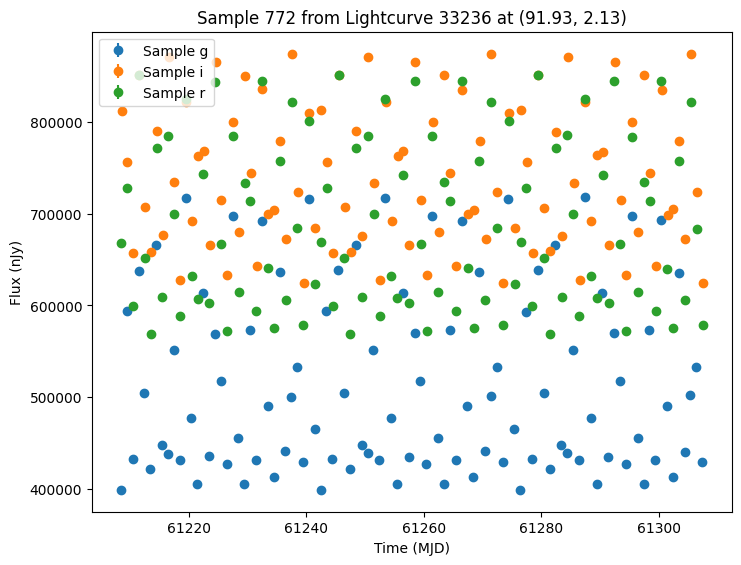

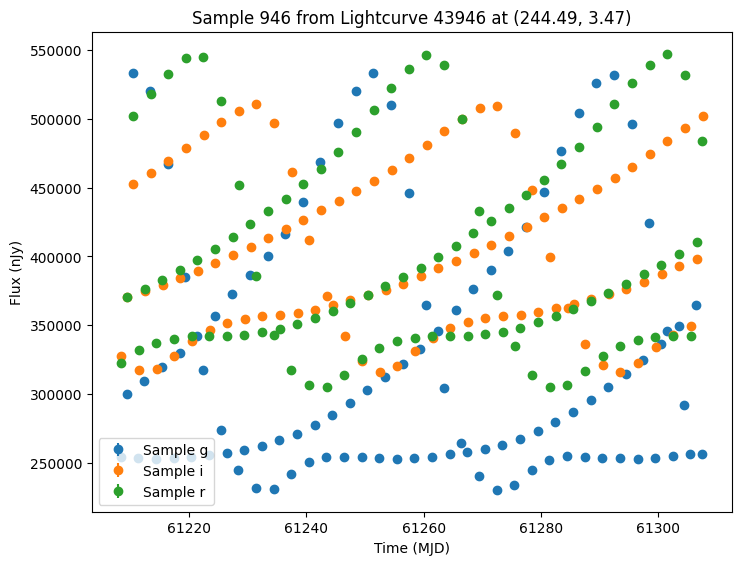

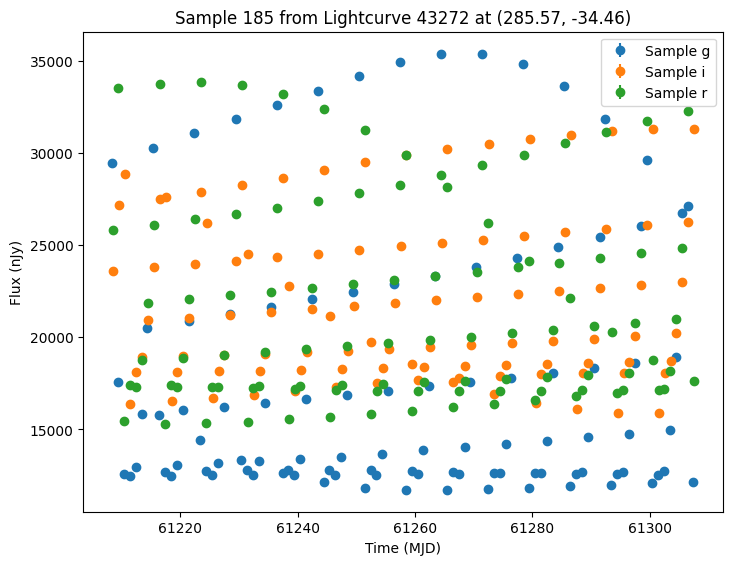

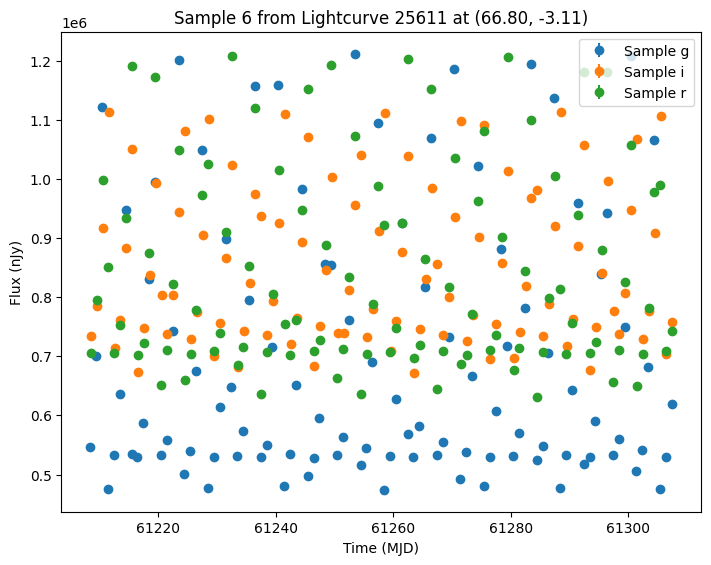

In [10]:
plot_some_lightcurves(lightcurves_new_obs, random_ids)

We could also generate samples of both survey's together by passing a `list` of survey info. Again we pass the extracted `GraphState` to ensure we are using the same models. Note that while the cadence will be the same for the first survey, we expect different noise values from rerunning the simulation.

Simulating: 100%|██████████| 1000/1000 [00:01<00:00, 980.66obj/s]


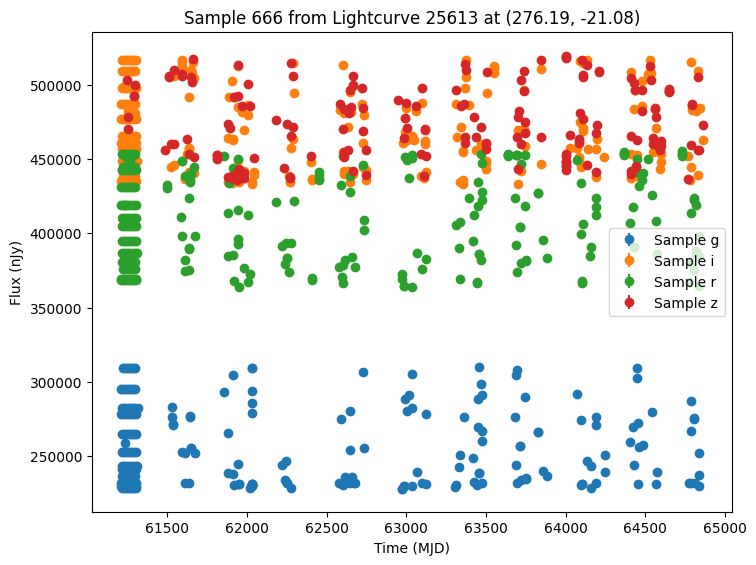

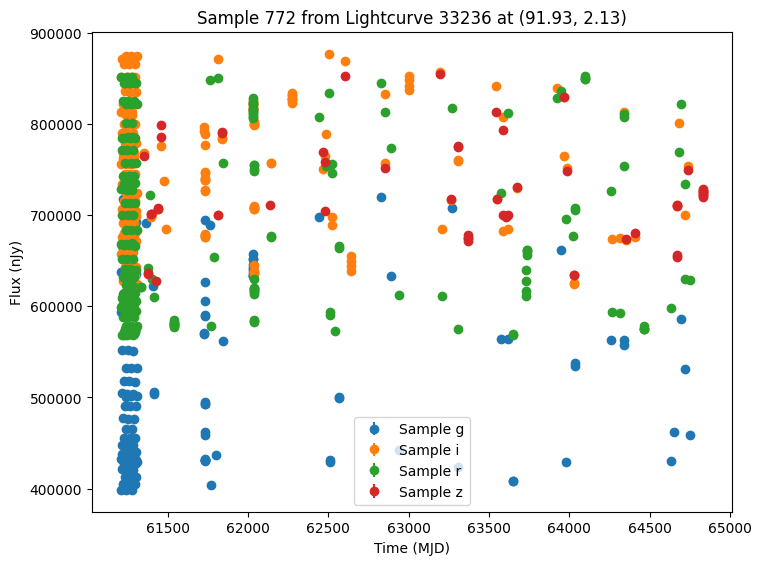

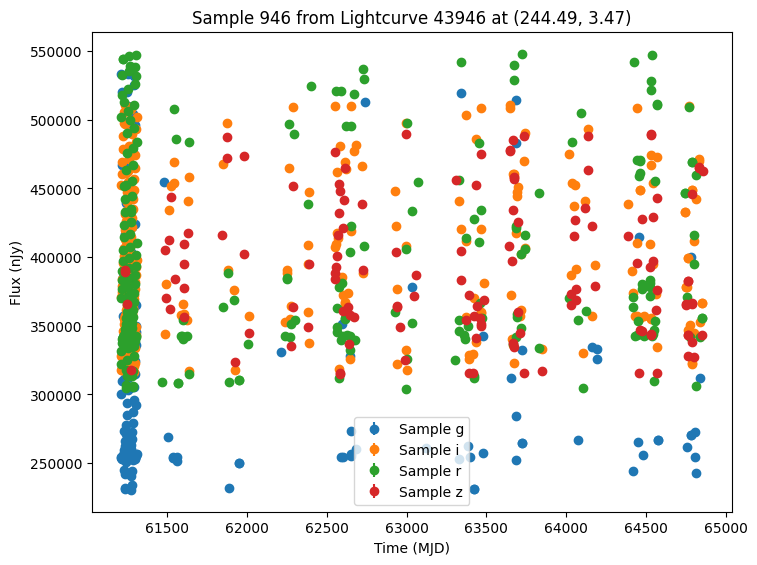

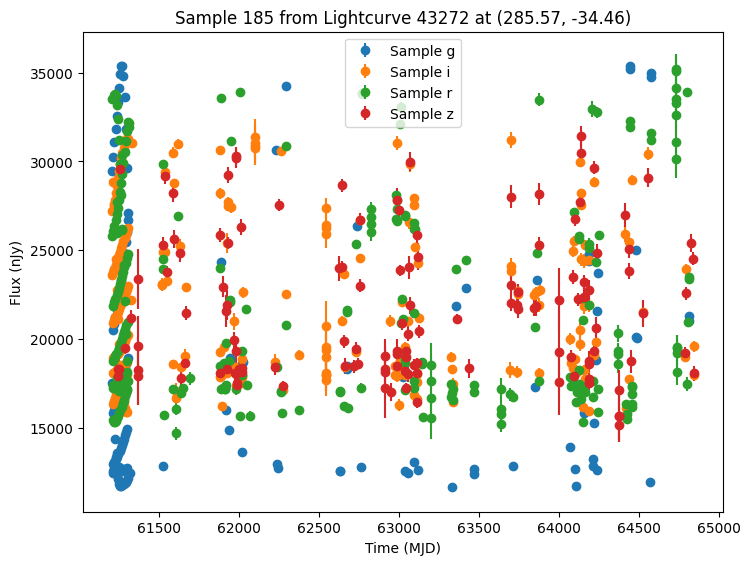

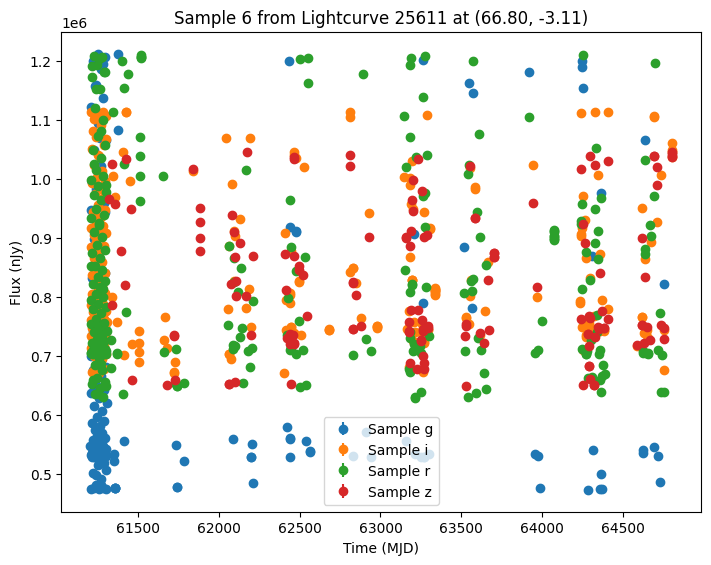

In [11]:
lightcurves_combined = simulate_lightcurves(
    source, 1_000, [survey_info, new_survey_info], graph_state=previous_state
)

plot_some_lightcurves(lightcurves_combined, random_ids)